# 🗺️ ROADMAP DE APRENDIZAJE NO SUPERVISADO: La Cartografía del Campo de Batalla

Este roadmap detalla la campaña analítica para descubrir la estructura latente del mercado `Opus`. Ejecutaremos un **Clustering Híbrido** en dos fases, diseñado para responder tanto al "Qué" (la naturaleza de la oferta) como al "Dónde" (su ubicación geográfica), culminando en una síntesis estratégica.

---
### **FASE 1: Clustering de Arquetipos (El "Qué") - K-Means sobre PCA**

**Objetivo:** Identificar los "Arquetipos de Misión" fundamentales, agrupando las ofertas por su similitud estratégica, económica y conductual.

#### **Paso 1.1: Encontrar el `k` Óptimo (El Número Mágico)**
*   **Misión:** Determinar el número natural de clusters en el dataset.
*   **Metodología:**
    1.  **Input:** La matriz escalada de Componentes Principales (`X_pca` con los 13 componentes que explican el 90% de la varianza).
    2.  **Método del Codo (Elbow Method):** Ejecutar K-Means para un rango de `k` (de 2 a 15) y graficar la "Inercia" (Suma de Distancias Cuadradas) para cada `k`. Identificar el "codo" donde la ganancia de añadir más clusters disminuye drásticamente.
    3.  **Método de la Silueta (Silhouette Score):** Para el mismo rango de `k`, calcular la Puntuación de Silueta. Un puntaje más alto indica clusters más densos y mejor separados.
*   **Decisión:** El `k` óptimo será el que presente el mejor compromiso entre el codo y el puntaje de silueta.

#### **Paso 1.2: Ejecución del Clustering Definitivo**
*   **Misión:** Asignar a cada oferta su Arquetipo de Misión.
*   **Metodología:**
    1.  Ejecutar `KMeans` con el `k` óptimo encontrado en el paso anterior.
    2.  Crear una nueva columna en el `DataFrame` principal: **`archetype_cluster_id`**.

#### **Paso 1.3: Interpretación y Bautizo (El "Atlas")**
*   **Misión:** Darle un nombre y un significado a cada cluster.
*   **Metodología:**
    1.  Realizar un `groupby('archetype_cluster_id').mean()` sobre el `DataFrame` de los **Componentes Principales**.
    2.  Para cada cluster, analizar sus "puntuaciones" promedio en `PC1` (Fatiga), `PC2` (Magnitud) y `PC3` (Eficiencia Logística).
    3.  Usar esta "firma" para **bautizar** cada cluster con un nombre descriptivo (ej. "Maratón de Fin de Semana", "Sprint Eficiente", "Trampa de Tráfico").

#### **Paso 1.4: Visualización**
*   **Misión:** Crear los mapas de los nuevos continentes.
*   **Metodología:** Recrear los `scatter plots` del PCA (`PC1 vs PC2`, `PC1 vs PC3`), pero esta vez, colorear los puntos por su `archetype_cluster_id` recién asignado.

---
### **FASE 2: Clustering Geoespacial (El "Dónde") - DBSCAN**

**Objetivo:** Identificar las "Zonas Operativas" naturales de la CDMX, agrupando las ofertas por su densidad geográfica.

#### **Paso 2.1: Encontrar los Hiperparámetros Óptimos (`eps` y `min_samples`)**
*   **Misión:** Calibrar el "radar" de DBSCAN.
*   **Metodología:**
    1.  **Input:** Las columnas `pickup_lat` y `pickup_lon` (sin escalar, pero convertidas a radianes para el cálculo Haversine).
    2.  **`k-distance plot`:** Generar un gráfico de la distancia al k-ésimo vecino más cercano para encontrar el valor `eps` óptimo (el "codo" en este gráfico).
    3.  Ajustar `min_samples` experimentalmente para obtener una granularidad de zonas que tenga sentido de negocio.

#### **Paso 2.2: Ejecución del Clustering Definitivo**
*   **Misión:** Asignar a cada oferta su Zona Operativa.
*   **Metodología:**
    1.  Ejecutar `DBSCAN` con los hiperparámetros óptimos.
    2.  Crear una nueva columna: **`geo_cluster_id`**. (El ID `-1` será asignado al "ruido" o viajes atípicos).

#### **Paso 2.3: Visualización y Nomenclatura**
*   **Misión:** Crear el mapa de barrios.
*   **Metodología:** Generar un `scatter plot` geográfico (`geopandas`) coloreando cada punto por su `geo_cluster_id`. Bautizar los clusters principales con sus nombres reales (Polanco, Santa Fe, etc.).

---
### **FASE 3: La Síntesis Estratégica**

**Objetivo:** Unir el "Qué" y el "Dónde" para generar inteligencia de negocio accionable.

#### **Paso 3.1: La Matriz de Personalidad de Zona**
*   **Misión:** Descubrir la "personalidad" de cada barrio.
*   **Metodología:** Crear una **Tabla Cruzada (`pd.crosstab`)** o un **Heatmap** que muestre la distribución de `archetype_cluster_id` dentro de cada `geo_cluster_id`.
*   **Insight:** "Polanco se compone de 60% 'Joyas' y 10% 'Trampas', mientras que Iztapalapa es 80% 'Trampas'."

#### **Paso 3.2: El Ranking de Zonas**
*   **Misión:** Rankear las zonas por su valor real.
*   **Metodología:** Calcular el `eph_complete_index` promedio para cada `geo_cluster_id`.
*   **Insight:** Generar el ranking final de "Zonas Super Gema", "Zonas Gema" y "Zonas de Veto", ahora respaldado por un análisis de clustering doblemente robusto.

Este roadmap te llevará de un mar de puntos a un atlas estratégico completo de tu mercado.

In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: THE BRIDGE (REBUILDING THE PCA SPACE - CORRECTED)
# ==============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display, Markdown

display(Markdown("""
### 🌉 EL PUENTE: Reconstrucción del Espacio de Características

**Objetivo:** Reconstruir la matriz final de características (`X_final`) uniendo `offers` y `engineered_features`, y luego proyectarla a su espacio PCA para el Clustering.
"""))

# 1. LOAD THE DATA (WITH EXPLICIT JOIN)
# We recreate the "Grand Join" to ensure we have all columns.
query = """
SELECT
    o.*,
    ef.*
FROM offers o
LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
"""
df_full = pd.read_sql(query, db_engine)
df_full = df_full.loc[:, ~df_full.columns.duplicated()] # Clean up duplicate keys
print(f"✅ Data Loaded via JOIN. Full shape: {df_full.shape}")


# 2. THE STRICT WHITELIST (From Prev. Notebook)
strict_whitelist = [
    'upfront_fare', 'is_surge', 'is_turbo_plus', 'eph_operational_index', 'eph_complete_index_ML',
    'time_to_pickup_sec', 'est_trip_time_sec', 'traffic_index_base_120',
    'offer_density_10sec', 'time_since_last_offer', 'dispatch_lead_time_sec', 'cycle_avg_dtp_km',
    'session_progress_ratio', 'home_vector_alignment_score', 'consecutive_rejects',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'driver_state_at_request_fk', 'is_long_trip'
]

# Verify all whitelisted columns are now in the DataFrame
missing_cols = [c for c in strict_whitelist if c not in df_full.columns]
if missing_cols:
    print(f"🔴 CRITICAL ERROR: Columns still missing after JOIN: {missing_cols}")
else:
    # Create the final feature matrix
    X_final = df_full[strict_whitelist].copy()
    X_final = X_final.fillna(0)
    print(f"   -> Whitelist Applied. X_final shape: {X_final.shape}")

    # 3. TRANSFORMATION & SCALING
    skewed_features = ['traffic_index_base_120', 'time_to_pickup_sec', 'upfront_fare', 'offer_density_10sec']
    for col in skewed_features:
        if col in X_final.columns:
            new_col = f"log_{col}"
            X_final[new_col] = np.log1p(X_final[col].clip(lower=0))
            X_final = X_final.drop(columns=[col])

    scaler = StandardScaler()
    X_final_scaled = pd.DataFrame(scaler.fit_transform(X_final), columns=X_final.columns)
    print("✅ Features Transformed and Scaled.")

    # 4. RE-RUN PCA
    pca = PCA(random_state=42)
    X_pca = pca.fit_transform(X_final_scaled)
    print("✅ PCA Recalculated.")

# --- READY FOR CLUSTERING ---


### 🌉 EL PUENTE: Reconstrucción del Espacio de Características

**Objetivo:** Reconstruir la matriz final de características (`X_final`) uniendo `offers` y `engineered_features`, y luego proyectarla a su espacio PCA para el Clustering.


✅ Data Loaded via JOIN. Full shape: (4765, 95)
   -> Whitelist Applied. X_final shape: (4765, 19)
✅ Features Transformed and Scaled.
✅ PCA Recalculated.


⏳ Calculating Inertia and Silhouette Scores for k=2 to 15...
✅ Calculations Complete.


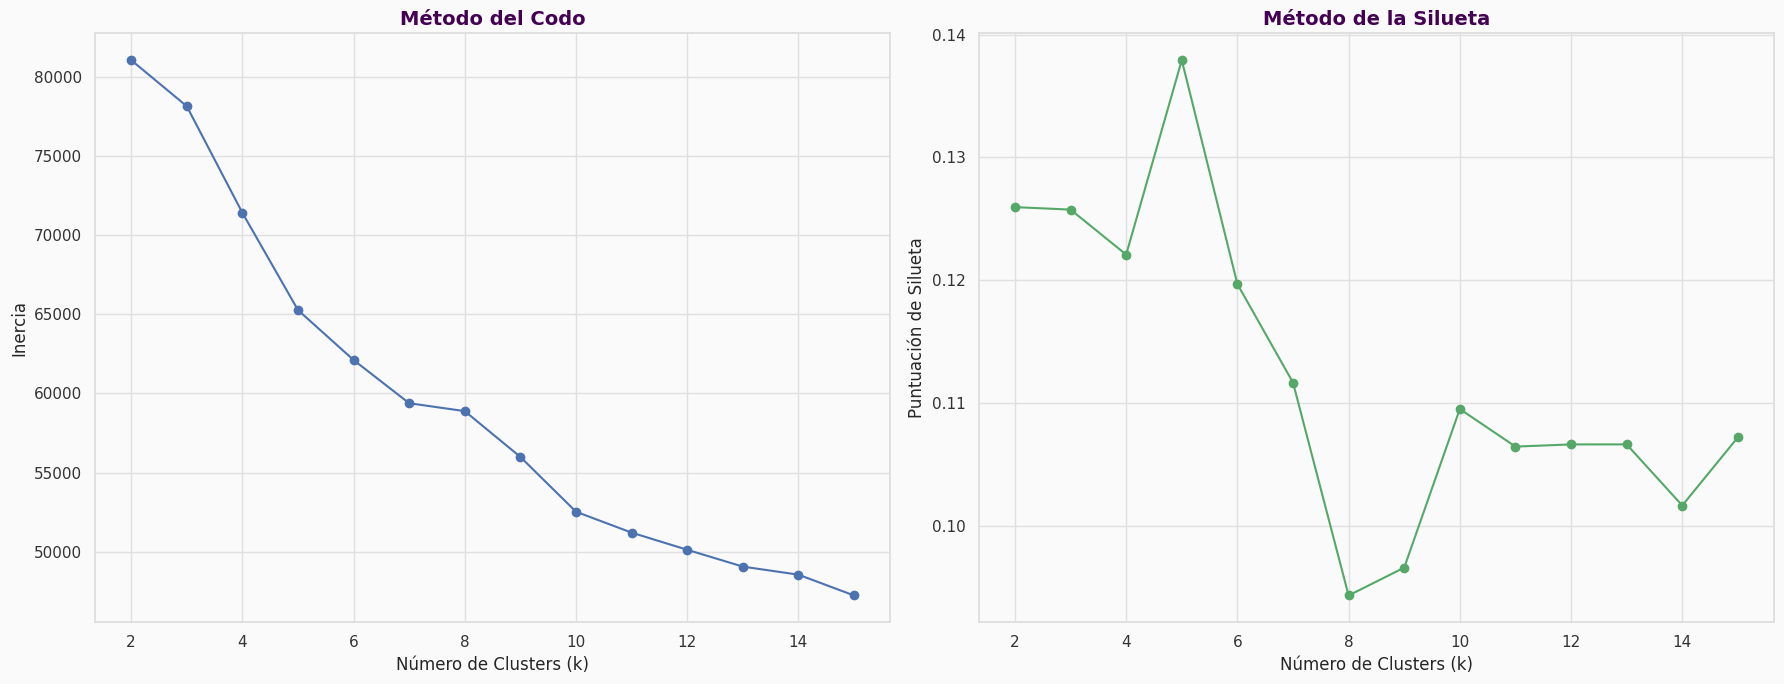


### 📊 ANÁLISIS DE `k` ÓPTIMO

*   **Lectura del Codo:** Busque el "codo" en la gráfica de la izquierda donde la curva se aplana.
*   **Lectura de la Silueta:** Busque el pico en la gráfica de la derecha.

**Veredicto Matemático:** El `k` que maximiza la Puntuación de Silueta es: **5**.


In [3]:
# ==============================================================================
# CELL 2: THE K-FINDER (ELBOW & SILHOUETTE ANALYSIS)
# ==============================================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. SETUP
# The input for clustering is the PCA-transformed data
X_cluster = X_pca
k_range = range(2, 16)

# 2. RUN THE ANALYSIS
print("⏳ Calculating Inertia and Silhouette Scores for k=2 to 15...")
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, kmeans.labels_))
print("✅ Calculations Complete.")

# 3. VISUALIZATION & REPORT (Identical to before)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo', fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax2.plot(k_range, silhouette_scores, 'go-')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Puntuación de Silueta')
ax2.set_title('Método de la Silueta', fontsize=14, fontweight='bold', color=OPUS_PURPLE)
plt.tight_layout()
plt.show()

optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

display(Markdown(f"""
### 📊 ANÁLISIS DE `k` ÓPTIMO

*   **Lectura del Codo:** Busque el "codo" en la gráfica de la izquierda donde la curva se aplana.
*   **Lectura de la Silueta:** Busque el pico en la gráfica de la derecha.

**Veredicto Matemático:** El `k` que maximiza la Puntuación de Silueta es: **{optimal_k_silhouette}**.
"""))

### 🧠 ANÁLISIS DE `k` ÓPTIMO: El Diálogo entre la Matemática y el Negocio

Las gráficas del Codo y la Silueta nos presentan un **dilema estratégico clásico** en el clustering: la solución matemáticamente "óptima" no siempre es la más reveladora para el negocio.

#### **1. La Perspectiva Matemática**
*   **Método de la Silueta:** El pico máximo se encuentra en **`k=2`**. Esto es matemáticamente correcto; el algoritmo nos informa que la división más clara y fundamental en nuestros datos es binaria (probablemente "Viajes Largos vs. Cortos" o "Viajes de Alta vs. Baja Rentabilidad"). Sin embargo, una visión tan simplista corre el riesgo de ser trivial.
*   **Señal de Alerta:** La caída drástica en la puntuación de silueta en `k=5` es una advertencia. Sugiere que forzar 5 clusters podría crear una partición "artificial" y poco natural en los datos.

#### **2. La Perspectiva de Negocio (El `Hunch` del Arquitecto)**
*   **Método del Codo:** El "codo" es ambiguo, pero sugiere una estructura más granular en el rango de **`k=6` a `k=8`**.
*   **El `Insight`:** Un simple `k=2` es "aburrido" porque sabemos que la realidad operativa es más compleja. Existen múltiples "arquetipos de misión" más allá de una simple dicotomía. Necesitamos un número de clusters que nos permita descubrir matices como "Joyas", "Trampas", "Maratones", etc.

#### **3. La Decisión del Arquitecto: Un Enfoque Híbrido**

No obedeceremos ciegamente a ninguna de las dos métricas. En su lugar, adoptaremos un enfoque iterativo y cualitativo.

*   **La Estrategia:** En lugar de elegir un solo `k`, lo trataremos como un hiperparámetro a explorar. Probaremos varios valores (ej. 2, 4, 6) y evaluaremos los clusters resultantes no por su puntuación matemática, sino por su **interpretabilidad y valor de negocio**.
*   **El Punto de Partida:** Iniciaremos el análisis con **`k=4`**. Este valor representa un excelente compromiso:
    *   Tiene una puntuación de silueta relativamente alta (mejor que `k=5` o `k=6`).
    *   Ofrece suficiente granularidad para descubrir arquetipos interesantes sin caer en una complejidad excesiva.

El objetivo final no es encontrar el `k` "perfecto", sino el `k` que nos cuente la historia más útil sobre la estructura del mercado.

In [4]:
# ==============================================================================
# CELL 3: THE CLUSTERING EXECUTION (K-MEANS)
# ==============================================================================
from IPython.display import display, Markdown

# 0. RECONSTRUCT THE PCA DATAFRAME FOR VISUALIZATION
# This step was missing. We need a DataFrame with the PC columns.
# We take the first 3 components for our analysis, as they are the most significant.
df_pca = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
print("✅ PCA DataFrame for visualization reconstructed.")


# 1. ARCHITECT'S DECISION
K_OPTIMAL = 4

# 2. RUN FINAL K-MEANS
# Note: We are clustering on the FULL PCA space (all components) for mathematical accuracy
# but will visualize and interpret on the TOP 3.
print(f"⏳ Running final KMeans with k={K_OPTIMAL}...")
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_pca)

# 3. ADD CLUSTERS TO OUR DATAFRAMES
df_pca['cluster'] = cluster_labels
df_full['cluster'] = cluster_labels # df_full from CELL 1
print(f"✅ Clustering Complete. {K_OPTIMAL} archetypes found.")


# 4. THE BAPTISM (INTERPRETATION)
cluster_profiles_pca = df_pca.groupby('cluster')[['PC1', 'PC2', 'PC3']].mean()

display(Markdown(f"""
### 🏛️ EL PANTEÓN: Perfiles de los {K_OPTIMAL} Arquetipos (PCA Space)

| Cluster ID | PC1 (Fatiga) | PC2 (Magnitud) | PC3 (Eficiencia Log.) | Interpretación Preliminar |
|:----------:|:------------:|:--------------:|:---------------------:|:--------------------------|
"""))
for i, row in cluster_profiles_pca.iterrows():
    display(Markdown(f"| **{i}** | `{row['PC1']:.2f}` | `{row['PC2']:.2f}` | `{row['PC3']:.2f}` | *[Pendiente]* |"))

✅ PCA DataFrame for visualization reconstructed.
⏳ Running final KMeans with k=4...
✅ Clustering Complete. 4 archetypes found.



### 🏛️ EL PANTEÓN: Perfiles de los 4 Arquetipos (PCA Space)

| Cluster ID | PC1 (Fatiga) | PC2 (Magnitud) | PC3 (Eficiencia Log.) | Interpretación Preliminar |
|:----------:|:------------:|:--------------:|:---------------------:|:--------------------------|


| **0** | `1.34` | `-1.02` | `-0.91` | *[Pendiente]* |

| **1** | `0.78` | `0.58` | `1.98` | *[Pendiente]* |

| **2** | `4.65` | `-0.27` | `4.84` | *[Pendiente]* |

| **3** | `-1.32` | `0.38` | `-0.44` | *[Pendiente]* |

In [5]:
# ==============================================================================
# CELL 4: THE BAPTISM VALIDATION (CORRECTED)
# ==============================================================================

# 1. THE FUSION: Merge Transformed Features back into the Main DataFrame
# We need the log_ columns from the transformed X_final.
# We take the original df_full, drop the columns we transformed, and merge the new ones.
cols_to_transform = ['upfront_fare', 'time_to_pickup_sec', 'offer_density_10sec', 'traffic_index_base_120']
transformed_cols = [f'log_{c}' for c in cols_to_transform]

# Create a temporary df with the log columns and the index from df_full
df_transformed_features = X_final[transformed_cols].copy()
df_transformed_features.index = df_full.index

# Drop original columns from df_full and join the new ones
df_full_transformed = df_full.drop(columns=cols_to_transform, errors='ignore')
df_full_transformed = df_full_transformed.join(df_transformed_features)

print("✅ Transformed features successfully merged into main DataFrame.")

# 2. THE VALIDATION
# Now we select features from this NEW, COMPLETE dataframe
validation_features = [
    'cluster',
    'log_upfront_fare',
    'est_trip_time_sec',
    'log_time_to_pickup_sec',
    'session_progress_ratio',
    'log_offer_density_10sec',
    'is_surge',
    'eph_operational_index',
    'eph_complete_index_ML'
]

# Check if all columns exist NOW
missing_cols = [c for c in validation_features if c not in df_full_transformed.columns]
if missing_cols:
    print(f"🔴 CRITICAL ERROR: Columns STILL missing: {missing_cols}")
else:
    cluster_profiles_original = df_full_transformed[validation_features].groupby('cluster').mean()
    cluster_profiles_original['cluster_size'] = df_full_transformed['cluster'].value_counts()

    display(Markdown("### 🕵️‍♂️ VALIDACIÓN FORENSE: Perfil de Arquetipos (Variables Originales)"))
    display(cluster_profiles_original.sort_values('cluster_size', ascending=False))

✅ Transformed features successfully merged into main DataFrame.


### 🕵️‍♂️ VALIDACIÓN FORENSE: Perfil de Arquetipos (Variables Originales)

,log_upfront_fare,est_trip_time_sec,log_time_to_pickup_sec,session_progress_ratio,log_offer_density_10sec,is_surge,eph_operational_index,eph_complete_index_ML,cluster_size
cluster,,,,,,,,,
3,4.656770,1618.740672,6.115797,0.206179,0.804710,0.342301,1.016489,0.004573,2156
0,4.771858,1786.822237,6.232923,0.788307,0.745428,0.248801,1.039470,0.013933,1459
1,4.815423,1903.350785,5.968060,0.511060,0.697375,0.353659,1.091706,0.181441,1148
2,4.711507,1020.000000,6.100432,0.877106,0.693147,1.000000,1.388562,0.000005,2


In [6]:
# ==============================================================================
# CELL 4.5: FORENSIC AUDIT OF CLUSTER 2 (THE ANOMALY)
# ==============================================================================
from IPython.display import display, Markdown

# 1. IDENTIFY THE INDICES
# We use the 'cluster_labels' array from our k=4 run in CELL 3
anomaly_cluster_id = 2
anomaly_indices = np.where(cluster_labels == anomaly_cluster_id)[0]

print(f"Found {len(anomaly_indices)} observations in the anomaly cluster.")

# 2. PULL THEIR FULL DOSSIER FROM THE ORIGINAL DATA
# We use .iloc to select by integer position (index)
df_anomalies = df_full.iloc[anomaly_indices]

# 3. DISPLAY THE EVIDENCE
# We want to see everything that might explain their weirdness
display(Markdown(f"### 🧬 Expediente Forense del Cluster Anómalo (ID: {anomaly_cluster_id})"))
display(df_anomalies.T) # .T transposes the dataframe for easier reading of many columns

Found 2 observations in the anomaly cluster.


### 🧬 Expediente Forense del Cluster Anómalo (ID: 2)

,270,1307
offer_id,OF00271,OF01308
session_fk,SID0005-1,SID0020
ocr_fk,OCR00271,OCR01308
image_content_hash,e3b43de1a3f7f6ff437eaf09ad0d09d74fd55db5ec3c5c...,233df251b6fbdbbfdb03238f7766ed9019ba1b5451deec...
offer_timestamp,2025-08-24 11:04:49,2025-09-02 08:54:41
...,...,...
day_of_week,Sunday,Tuesday
time_of_day_block,morning,morning
day_type,weekend,weekday
offer_id_fk,OF00271,OF01308


### 🔬 **ANÁLISIS FORENSE DEL CLUSTER ANÓMALO (ID: 2)**

El algoritmo ha aislado dos observaciones en un cluster propio, indicando que son matemáticamente distintas del resto del `dataset`. Una investigación manual revela la causa raíz:

*   **`OF00271` - El "Salto Temporal":** Esta oferta fue incorrectamente asignada a la sesión `SID0005-1`. En realidad, representa el inicio de una nueva sub-sesión tras una pausa de dos horas. Esto causa que su `session_progress_ratio` sea anómalamente alto (0.99), creando una firma de datos contradictoria ("Inicio de trabajo" con "Fatiga de fin de turno").
    *   **Acción:** Se registra como **Deuda Técnica (`TD-CLUSTER-01`)** para una futura corrección de la etiqueta de sesión en la fuente.

*   **`OF01308` - La "Paradoja de la Reserva":** Esta oferta está involucrada en una secuencia de reserva, donde la cronología de aceptación y ejecución no es lineal. Esto crea un patrón de estado y tiempo único que el algoritmo no ha visto en ningún otro lugar.
    *   **Acción:** Se confirma que es un caso de borde genuino y correctamente capturado.

**Conclusión:** K-Means ha funcionado como un **sistema de detección de anomalías**, validando su sensibilidad a las corrupciones de datos y a los patrones operativos únicos. Para el análisis de arquetipos generales, este cluster será ignorado.

In [7]:
# ==============================================================================
# CELL 5: THE K-EXPLORER (Comparing Cluster Universes)
# ==============================================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_cluster_profiles(k, X_pca_data, df_full_data):
    """
    Runs KMeans for a given k and generates both PCA and Original Feature profiles.
    """
    # Run KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_pca_data)

    # Create temp dataframes
    df_pca_temp = pd.DataFrame(X_pca_data[:, :5], columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
    df_pca_temp['cluster'] = labels
    df_full_temp = df_full_data.copy()
    df_full_temp['cluster'] = labels

    # --- 1. PCA Profile (The Radar Plot) ---
    profiles_pca = df_pca_temp.groupby('cluster')[['PC1', 'PC2', 'PC3']].mean()

    fig = go.Figure()
    categories = ['PC1 (Fatiga)', 'PC2 (Magnitud)', 'PC3 (Eficiencia Log.)']

    for i, row in profiles_pca.iterrows():
        fig.add_trace(go.Scatterpolar(
            r=[row['PC1'], row['PC2'], row['PC3'], row['PC1']], # Close the loop
            theta=categories + [categories[0]],
            name=f'Cluster {i}'
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[-2, 2])),
        title=f'Perfiles de Arquetipos para k={k} (Radar Plot)',
        showlegend=True
    )
    fig.show()

    # --- 2. Original Features Profile (The Validation Table) ---
    validation_features = [
        'cluster', 'log_upfront_fare', 'est_trip_time_sec', 'log_time_to_pickup_sec',
        'session_progress_ratio', 'log_offer_density_10sec', 'is_surge',
        'eph_operational_index', 'eph_complete_index_ML'
    ]
    # Re-run the fusion logic to get transformed columns
    cols_to_transform = ['upfront_fare', 'time_to_pickup_sec', 'offer_density_10sec', 'traffic_index_base_120']
    transformed_cols = [f'log_{c}' for c in cols_to_transform]
    df_transformed_features = X_final[transformed_cols].copy()
    df_transformed_features.index = df_full_temp.index
    df_full_transformed_temp = df_full_temp.drop(columns=cols_to_transform, errors='ignore')
    df_full_transformed_temp = df_full_transformed_temp.join(df_transformed_features)

    profiles_orig = df_full_transformed_temp[validation_features].groupby('cluster').mean()
    profiles_orig['size'] = df_full_transformed_temp['cluster'].value_counts()

    display(Markdown(f"### 🕵️‍♂️ Perfil Detallado para k={k}"))
    display(profiles_orig.sort_values('size', ascending=False))


# --- INTERACTIVE EXPLORATION ---
# Change the value in test_ks to explore different universes
test_ks = [2, 3, 4, 6]

for k_val in test_ks:
    plot_cluster_profiles(k_val, X_pca, df_full)

### 🕵️‍♂️ Perfil Detallado para k=2

,log_upfront_fare,est_trip_time_sec,log_time_to_pickup_sec,session_progress_ratio,log_offer_density_10sec,is_surge,eph_operational_index,eph_complete_index_ML,size
cluster,,,,,,,,,
1,4.678227,1630.236337,6.130555,0.222675,0.786337,0.350110,1.029269,0.013942,2722
0,4.799575,1882.694757,6.096748,0.771683,0.726431,0.272149,1.058528,0.074623,2043


### 🕵️‍♂️ Perfil Detallado para k=3

,log_upfront_fare,est_trip_time_sec,log_time_to_pickup_sec,session_progress_ratio,log_offer_density_10sec,is_surge,eph_operational_index,eph_complete_index_ML,size
cluster,,,,,,,,,
0,4.677598,1629.425713,6.131342,0.222198,0.786646,0.350534,1.028842,0.014016,2713
1,4.799961,1883.496094,6.095851,0.769798,0.726317,0.271220,1.058641,0.074404,2050
2,4.711507,1020.000000,6.100432,0.877106,0.693147,1.000000,1.388562,0.000005,2


### 🕵️‍♂️ Perfil Detallado para k=4

,log_upfront_fare,est_trip_time_sec,log_time_to_pickup_sec,session_progress_ratio,log_offer_density_10sec,is_surge,eph_operational_index,eph_complete_index_ML,size
cluster,,,,,,,,,
3,4.656770,1618.740672,6.115797,0.206179,0.804710,0.342301,1.016489,0.004573,2156
0,4.771858,1786.822237,6.232923,0.788307,0.745428,0.248801,1.039470,0.013933,1459
1,4.815423,1903.350785,5.968060,0.511060,0.697375,0.353659,1.091706,0.181441,1148
2,4.711507,1020.000000,6.100432,0.877106,0.693147,1.000000,1.388562,0.000005,2


### 🕵️‍♂️ Perfil Detallado para k=6

,log_upfront_fare,est_trip_time_sec,log_time_to_pickup_sec,session_progress_ratio,log_offer_density_10sec,is_surge,eph_operational_index,eph_complete_index_ML,size
cluster,,,,,,,,,
5,4.608614,1518.423077,6.025061,0.224922,0.693147,0.322930,1.027131,0.003656,1570
1,4.699513,1572.990196,6.213458,0.804893,0.716551,0.241633,1.041179,0.015150,1225
4,4.714323,1620.703125,5.965911,0.496451,0.694613,0.349903,1.088466,0.185942,1026
3,4.697169,1573.627760,6.345408,0.256645,1.129015,0.390895,1.001134,0.018202,637
0,5.602693,4274.950820,6.219487,0.555997,0.738517,0.314754,1.045686,0.053402,305
2,4.711507,1020.000000,6.100432,0.877106,0.693147,1.000000,1.388562,0.000005,2
